<a href="https://colab.research.google.com/github/irfan060606/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 4: Regression and Prediction

Notebook ini merupakan reproduksi dan pendalaman konsep Bab 4 *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck).

Bab ini berfokus pada penggunaan regresi untuk menjelaskan hubungan antarvariabel dan terutama untuk membuat prediksi. Contoh utama menggunakan data penjualan rumah di King County.

**Alur bab:**
1. Simple Linear Regression
2. Multiple Linear Regression
3. Prediction Using Regression
4. Factor Variables in Regression
5. Interpreting the Regression Equation
6. Regression Diagnostics
7. Polynomial and Spline Regression
8. Generalized Additive Models (GAM)

Dataset yang digunakan adalah `house_sales.csv` dari repositori data buku.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.precision", 4)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
house = pd.read_csv(BASE + "house_sales.csv", sep="\t")

# Buku menggunakan data rumah dan pada contoh utama memfokuskan pada Single Family.
house = house.loc[house["PropertyType"] == "Single Family"].copy()

print("Ukuran data:", house.shape)
house.head()


Ukuran data: (20720, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.9292,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.9779,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.9614,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.8079,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
7,2013-08-28,327500,3800004,Single Family,2013-08-01,374300,0.8601,380785.0,1,34465,...,1.50,3,8,1961,0,0,165000,227000,98178,False


In [2]:
house[["AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7
7,380785.0,1750,34465,1.50,3,8


## 1. Simple Linear Regression

**Regresi linear sederhana** memodelkan hubungan antara satu variabel response (Y) dan satu variabel predictor (X) sebagai garis lurus:

Y = b0 + b1 X + e

- **b0 (intercept)**: nilai Y yang diprediksi kalau X = 0.
- **b1 (slope/koefisien)**: seberapa besar Y berubah untuk tiap kenaikan 1 satuan pada X.
- **e (residual/error)**: selisih antara nilai Y yang sebenarnya dan yang diprediksi model, karena jarang sekali titik data persis jatuh di garis.

Garis terbaik dicari dengan **least squares**, yaitu meminimalkan jumlah kuadrat semua residual. Contoh di buku: memprediksi `AdjSalePrice` dari `SqFtTotLiving` (luas bangunan).

In [3]:
model_sederhana = smf.ols("AdjSalePrice ~ SqFtTotLiving", data=house).fit()
print(model_sederhana.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                 1.950e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:52:07   Log-Likelihood:            -2.8973e+05
No. Observations:               20720   AIC:                         5.795e+05
Df Residuals:                   20718   BIC:                         5.795e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -6.106e+04   4972.846    -12.278

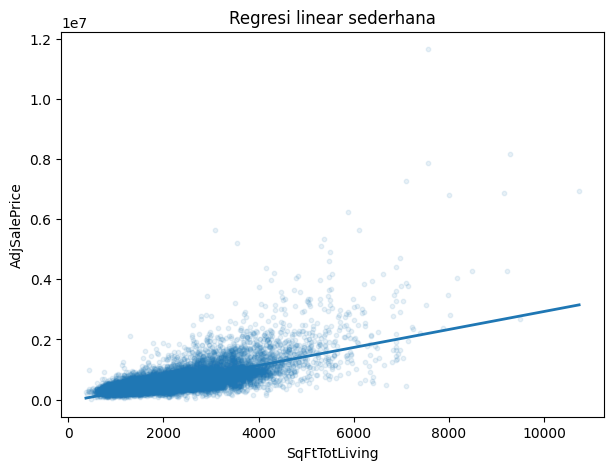

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(house["SqFtTotLiving"], house["AdjSalePrice"], alpha=0.1, s=10)

x_range = np.linspace(
    house["SqFtTotLiving"].min(),
    house["SqFtTotLiving"].max(),
    100
)
y_pred = (
    model_sederhana.params["Intercept"]
    + model_sederhana.params["SqFtTotLiving"] * x_range
)

ax.plot(x_range, y_pred, linewidth=2)
ax.set_xlabel("SqFtTotLiving")
ax.set_ylabel("AdjSalePrice")
ax.set_title("Regresi linear sederhana")
plt.show()


In [5]:
intercept = model_sederhana.params["Intercept"]
slope = model_sederhana.params["SqFtTotLiving"]

print(f"Intercept (b0): {intercept:,.0f}")
print(f"Slope (b1)    : {slope:,.2f}")
print(f"\nArtinya, tiap tambahan 1 sqft luas bangunan, harga rumah diprediksi naik sekitar {slope:,.0f} dolar.")

Intercept (b0): -61,058
Slope (b1)    : 298.81

Artinya, tiap tambahan 1 sqft luas bangunan, harga rumah diprediksi naik sekitar 299 dolar.


**Fitted values** adalah nilai Y hasil prediksi model untuk tiap data (titik-titik di garis merah), sementara **residuals** adalah selisih antara nilai asli dan fitted value-nya. Residual inilah yang nanti jadi dasar banyak diagnostik di bagian akhir bab ini.

In [6]:
fitted_values = model_sederhana.fittedvalues
residuals = model_sederhana.resid

print("Contoh fitted values:\n", fitted_values.head())
print("\nContoh residuals:\n", residuals.head())
print(f"\nRMSE (root mean squared error): {np.sqrt((residuals ** 2).mean()):,.0f}")
print(f"R-squared                      : {model_sederhana.rsquared:.3f}")

Contoh fitted values:
 2    1.0637e+06
3    5.5450e+05
4    8.9515e+05
5    4.5290e+05
7    4.6187e+05
dtype: float64

Contoh residuals:
 2     12485.4281
3    207307.0697
4   -453080.6130
5   -155836.2530
7    -81080.6657
dtype: float64

RMSE (root mean squared error): 286,128
R-squared                      : 0.485


## 2. Multiple Linear Regression

Kalau predictornya lebih dari satu, modelnya jadi **multiple linear regression**:

Y = b0 + b1 X1 + b2 X2 + ... + bp Xp + e

Interpretasi tiap koefisien jadi sedikit lebih rumit: bi menunjukkan perubahan Y untuk tiap kenaikan 1 satuan Xi, **dengan asumsi semua predictor lain tetap konstan**. Buku memakai beberapa predictor sekaligus untuk memprediksi harga rumah: luas bangunan, luas tanah, jumlah kamar mandi, jumlah kamar tidur, dan grade bangunan.

In [7]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
formula = "AdjSalePrice ~ " + " + ".join(predictors)

model_multiple = smf.ols(formula, data=house).fit()
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     4834.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:52:25   Log-Likelihood:            -2.8859e+05
No. Observations:               20720   AIC:                         5.772e+05
Df Residuals:                   20714   BIC:                         5.772e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.246e+05   1.69e+04    -31.060

In [8]:
print(f"RMSE      : {np.sqrt(model_multiple.mse_resid):,.0f}")
print(f"R-squared : {model_multiple.rsquared:.3f}")
print(f"Adjusted R-squared: {model_multiple.rsquared_adj:.3f}")

RMSE      : 270,842
R-squared : 0.539
Adjusted R-squared: 0.538


### Menilai model

Buku menekankan dua ukuran penting untuk regresi: **RMSE** dan **R-squared**.

- **RMSE (Root Mean Squared Error)** mengukur besar kesalahan prediksi dalam satuan response.
- **R-squared (R²)** menunjukkan proporsi variasi response yang dijelaskan oleh model.
- Untuk tujuan prediksi, evaluasi pada data yang tidak digunakan untuk fitting lebih penting daripada hanya melihat kecocokan in-sample.


In [9]:
# RMSE dihitung dari residual pada data yang digunakan untuk fitting.
rmse = np.sqrt(np.mean(model_multiple.resid ** 2))

print(f"RMSE      : {rmse:,.0f}")
print(f"R-squared : {model_multiple.rsquared:.4f}")
print(f"Adjusted R-squared: {model_multiple.rsquared_adj:.4f}")


RMSE      : 270,803
R-squared : 0.5385
Adjusted R-squared: 0.5384


### Cross-validation

Cross-validation membagi data menjadi bagian training dan validation secara berulang. Tujuannya adalah melihat seberapa baik model bekerja pada data yang tidak dipakai untuk fitting.

Contoh berikut menggunakan 5-fold cross-validation secara manual agar alurnya terlihat jelas.


In [10]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

X = house[predictors]
y = house["AdjSalePrice"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = []

for train_idx, test_idx in kf.split(X):
    model_cv = LinearRegression()
    model_cv.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model_cv.predict(X.iloc[test_idx])
    cv_rmse.append(np.sqrt(mean_squared_error(y.iloc[test_idx], pred)))

print("RMSE tiap fold:", np.round(cv_rmse, 0))
print("Rata-rata CV RMSE:", round(np.mean(cv_rmse), 0))


RMSE tiap fold: [260133. 254802. 267425. 291128. 280324.]
Rata-rata CV RMSE: 270762.0


### Model selection dan stepwise regression

Buku membahas model selection, termasuk pendekatan **forward selection**, **backward elimination**, dan **stepwise regression**. Ide dasarnya adalah memilih predictor yang memberikan model yang berguna, tetapi perlu berhati-hati karena pemilihan berdasarkan data training dapat menyebabkan overfitting.

Untuk tugas ini, contoh berikut hanya menunjukkan perbandingan model menggunakan AIC; ini bukan berarti model dengan AIC terkecil otomatis paling baik untuk semua tujuan.


In [11]:
candidate_models = {
    "5 predictors": model_multiple,
    "tanpa Bedrooms": smf.ols(
        "AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + BldgGrade",
        data=house
    ).fit(),
    "3 predictors": smf.ols(
        "AdjSalePrice ~ SqFtTotLiving + Bathrooms + BldgGrade",
        data=house
    ).fit(),
}

pd.DataFrame({
    "Model": list(candidate_models.keys()),
    "AIC": [m.aic for m in candidate_models.values()],
    "R_squared": [m.rsquared for m in candidate_models.values()],
}).sort_values("AIC")


,Model,AIC,R_squared
0,5 predictors,577191.7981,0.5385
2,3 predictors,577561.2116,0.5301
1,tanpa Bedrooms,577563.2111,0.5301


### Weighted Regression

Weighted regression memberi bobot berbeda pada observasi. Dalam contoh buku, bobot untuk data rumah dibuat dari tahun penjualan sehingga observasi yang lebih baru memperoleh bobot lebih besar.



In [12]:
house["Year"] = house["DocumentDate"].str.split("-").str[0].astype(int)
house["Weight"] = house["Year"] - 2005

model_weighted = smf.wls(
    formula,
    data=house,
    weights=house["Weight"]
).fit()

comparison = pd.DataFrame({
    "ordinary": model_multiple.params,
    "weighted": model_weighted.params
})

comparison


,ordinary,weighted
Intercept,-524602.9323,-590527.2539
SqFtTotLiving,228.1369,243.8593
SqFtLot,-0.0769,-0.3080
Bathrooms,-20372.1814,-28229.0384
Bedrooms,-53036.4823,-59861.0365
BldgGrade,109396.5303,119894.4444


Perhatikan bahwa koefisien `Bedrooms` di model ini bernilai **negatif**, padahal secara intuisi rumah dengan lebih banyak kamar tidur biasanya lebih mahal. Ini contoh nyata kenapa interpretasi "dengan predictor lain tetap konstan" penting: pada luas bangunan yang sama, menambah kamar tidur berarti kamar-kamarnya jadi lebih kecil, yang justru dianggap kurang diinginkan pembeli. Fenomena ini akan dibahas lebih lanjut di bagian korelasi antar predictor.

## 3. Prediction Using Regression

Setelah model terbentuk, kita bisa memakainya untuk **memprediksi** nilai Y pada data baru. Tapi penting membedakan dua jenis interval ketidakpastian:

- **Confidence interval**: rentang ketidakpastian untuk nilai rata-rata prediksi (misalnya, rata-rata harga rumah dengan karakteristik tertentu).
- **Prediction interval**: rentang ketidakpastian untuk satu observasi baru yang spesifik. Selalu lebih lebar dari confidence interval, karena menambahkan variasi dari residual individual, bukan cuma ketidakpastian dari estimasi rata-ratanya.

In [13]:
rumah_baru = pd.DataFrame({
    "SqFtTotLiving": [2500],
    "SqFtLot": [6000],
    "Bathrooms": [2],
    "Bedrooms": [3],
    "BldgGrade": [8],
})

prediksi = model_multiple.get_prediction(rumah_baru)
ringkasan_prediksi = prediksi.summary_frame(alpha=0.05)
ringkasan_prediksi

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,720596.0952,3040.2124,714637.0402,726555.1502,189691.4357,1.2515e+06


Kolom `mean_ci_lower`/`mean_ci_upper` adalah confidence interval untuk rata-rata, sementara `obs_ci_lower`/`obs_ci_upper` adalah prediction interval untuk satu rumah baru, jauh lebih lebar karena memperhitungkan variasi harga antar rumah individual, bukan cuma ketidakpastian estimasi rata-ratanya.

### Dangers of extrapolation

**Extrapolation** berarti menggunakan model di luar rentang predictor yang tersedia saat model dilatih. Buku memperingatkan bahwa regresi sebaiknya tidak digunakan begitu saja untuk nilai predictor yang berada jauh di luar data training.

Sebelum membuat prediksi, bandingkan nilai predictor baru dengan rentang data training.


In [14]:
ranges = house[predictors].agg(["min", "max"]).T
ranges["new_value"] = rumah_baru[predictors].iloc[0]

ranges["inside_training_range"] = (
    (ranges["new_value"] >= ranges["min"]) &
    (ranges["new_value"] <= ranges["max"])
)

ranges


,min,max,new_value,inside_training_range
SqFtTotLiving,370.0,10740.0,2500,True
SqFtLot,875.0,1024068.0,6000,True
Bathrooms,0.0,8.0,2,True
Bedrooms,0.0,33.0,3,True
BldgGrade,3.0,13.0,8,True


### Bootstrap untuk interval prediksi

Buku juga menjelaskan bootstrap sebagai pendekatan untuk membangun interval. Untuk interval prediksi individual, selain ketidakpastian model, residual individual perlu ikut diperhitungkan.

Contoh berikut adalah implementasi sederhana: ambil bootstrap sample, fit ulang regresi, prediksi rumah baru, lalu tambahkan satu residual acak dari model asli.


In [15]:
rng = np.random.default_rng(42)
n_boot = 300
bootstrap_predictions = []

for _ in range(n_boot):
    sample_idx = rng.integers(0, len(house), len(house))
    sample = house.iloc[sample_idx]

    boot_model = smf.ols(formula, data=sample).fit()
    pred = float(boot_model.predict(rumah_baru).iloc[0])

    residual = rng.choice(model_multiple.resid.to_numpy())
    bootstrap_predictions.append(pred + residual)

bootstrap_predictions = np.array(bootstrap_predictions)

pd.Series(
    np.quantile(bootstrap_predictions, [0.025, 0.5, 0.975]),
    index=["2.5%", "50%", "97.5%"]
)


,0
2.5%,3.6023e+05
50%,7.1469e+05
97.5%,1.0667e+06


## 4. Factor Variables dalam Regresi

Variabel kategorikal (disebut **factor variable** di buku) tidak bisa langsung dimasukkan ke persamaan regresi karena bukan angka. Solusinya adalah **one-hot encoding** / **dummy variable**: tiap kategori (kecuali satu yang jadi referensi) diubah jadi kolom biner 0/1.

`statsmodels` dengan formula API (seperti dipakai di atas) sebenarnya sudah menangani ini otomatis kalau kolomnya bertipe kategorikal/string, tapi penting memahami apa yang terjadi di baliknya.

In [16]:
print("Kategori PropertyType yang tersisa:", house['PropertyType'].unique())

contoh_zip = house[house["ZipCode"].isin([98105, 98108, 98126])][["ZipCode"]].copy()
pd.get_dummies(contoh_zip["ZipCode"], prefix="Zip").head()

Kategori PropertyType yang tersisa: ['Single Family']


,Zip_98105,Zip_98108,Zip_98126
47,False,True,False
71,False,False,True
72,False,False,True
117,False,False,True
118,False,False,True


Satu kategori selalu dijadikan **referensi** (tidak dibuatkan kolom dummy sendiri) supaya tidak terjadi multikolinearitas sempurna antar kolom dummy. Koefisien tiap dummy lainnya diinterpretasikan relatif terhadap kategori referensi ini.

Untuk variabel kategorikal dengan sangat banyak level seperti `ZipCode` (puluhan kode pos), buku menyarankan mengelompokkannya dulu, misalnya berdasarkan median harga rumah di tiap zip code, supaya tidak menghasilkan terlalu banyak kolom dummy sekaligus.

In [17]:
house["ZipGroup"] = pd.qcut(
    house.groupby("ZipCode")["AdjSalePrice"].transform("median"),
    q=5,
    labels=["grup_1_termurah", "grup_2", "grup_3", "grup_4", "grup_5_termahal"],
)

house.groupby("ZipGroup", observed=True)["AdjSalePrice"].median()

,AdjSalePrice
ZipGroup,
grup_1_termurah,322763.0
grup_2,391638.5
grup_3,488480.0
grup_4,585886.0
grup_5_termahal,771620.0


### Ordered factor variables

Beberapa categorical variable mempunyai urutan alami, misalnya grade rendah → sedang → tinggi. Buku membahas **ordered factor variables** karena urutan tersebut dapat memiliki makna yang berbeda dari kategori nominal biasa.


In [18]:
grade_summary = (
    house.groupby("BldgGrade", observed=True)["AdjSalePrice"]
    .agg(["count", "median"])
    .sort_index()
)

grade_summary.head(10)


,count,median
BldgGrade,,
3,1,77667.0
4,12,236248.0
5,186,251610.5
6,2039,311819.0
7,8828,404000.5
8,5220,548567.0
9,2688,737734.5
10,1174,935924.0
11,433,1378167.0


## 5. Menginterpretasikan Persamaan Regresi

Beberapa hal yang perlu diwaspadai saat membaca hasil regresi:

- **Correlated predictors (multikolinearitas)**: kalau dua predictor saling berkorelasi tinggi, koefisien keduanya jadi tidak stabil dan sulit diinterpretasikan sendiri-sendiri, seperti contoh `Bedrooms` di atas.
- **Confounding variables**: variabel penting yang tidak dimasukkan ke model, padahal sebenarnya memengaruhi baik predictor maupun response, bisa membuat hubungan yang terlihat jadi menyesatkan.
- **Interactions**: pengaruh satu predictor terhadap Y bisa berbeda tergantung nilai predictor lain, ini perlu ditambahkan secara eksplisit sebagai suku interaksi di model.

In [19]:
house[predictors].corr().round(3)

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
SqFtTotLiving,1.000,0.183,0.802,0.590,0.803
SqFtLot,0.183,1.000,0.118,0.052,0.150
Bathrooms,0.802,0.118,1.000,0.567,0.684
Bedrooms,0.590,0.052,0.567,1.000,0.409
BldgGrade,0.803,0.150,0.684,0.409,1.000


In [20]:
model_interaksi = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving * ZipGroup + Bathrooms + Bedrooms + BldgGrade",
    data=house,
).fit()
print(model_interaksi.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     2957.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:53:35   Log-Likelihood:            -2.8626e+05
No. Observations:               20720   AIC:                         5.725e+05
Df Residuals:                   20707   BIC:                         5.726e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

Istilah `SqFtTotLiving:ZipGroup[...]` pada hasil ini menunjukkan seberapa besar pengaruh luas bangunan terhadap harga berbeda-beda antar kelompok zip code. Kalau koefisien interaksinya signifikan, itu tanda bahwa "harga per sqft" memang tidak seragam di semua wilayah.

### Confounding variables

**Confounding variable** adalah predictor penting yang tidak dimasukkan ke model, tetapi berhubungan dengan predictor dan response. Akibatnya, koefisien yang terlihat pada model dapat mencampurkan beberapa hubungan sekaligus.

Pada data rumah, **lokasi** merupakan contoh penting. Harga rumah dipengaruhi lokasi, sementara ukuran dan karakteristik rumah juga dapat berbeda menurut lokasi. Karena itu, hubungan antar predictor harus dibaca sebagai hubungan statistik, bukan bukti sebab-akibat.


## 6. Menguji Asumsi: Regression Diagnostics

Model regresi mengasumsikan beberapa hal soal residualnya. Buku memakai subset data dari satu zip code (98105) untuk mendemonstrasikan diagnostik ini, supaya pola-polanya lebih mudah terlihat dibanding memakai seluruh data King County sekaligus.

In [21]:
house_98105 = house.loc[house["ZipCode"] == 98105].copy()

model_98105 = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     212.7
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.99e-91
Time:                        18:53:41   Log-Likelihood:                -3734.3
No. Observations:                 276   AIC:                             7481.
Df Residuals:                     270   BIC:                             7502.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -8.345e+05   1.07e+05     -7.774

### Outliers

**Outlier** dalam konteks regresi adalah observasi yang residualnya jauh lebih besar dibanding yang lain, lebih mudah dideteksi dari residualnya dibanding dari nilai mentahnya sendiri.

In [22]:
residuals_98105 = model_98105.resid
std_residuals = residuals_98105 / residuals_98105.std()

outlier_idx = std_residuals.abs().idxmax()
print(f"Index observasi dengan residual paling ekstrem: {outlier_idx}")
print(f"Standardized residual: {std_residuals.loc[outlier_idx]:.2f}")
house_98105.loc[[outlier_idx]]

Index observasi dengan residual paling ekstrem: 14392
Standardized residual: 4.97


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight,ZipGroup
14392,2011-08-01,1650000,4219400785,Single Family,2011-08-01,312700,0.7185,2296386.0,1,7200,...,1936,0,0,467000,1112000,98105,False,2011,6,grup_4


### Influential Values

Tidak semua outlier sama bahayanya bagi model. **Influential value** adalah observasi yang kalau dihapus, benar-benar mengubah hasil model secara signifikan, ini kombinasi antara seberapa ekstrem nilai predictornya (**leverage**) dan seberapa besar residualnya. Ukuran yang umum dipakai adalah **Cook's distance**.

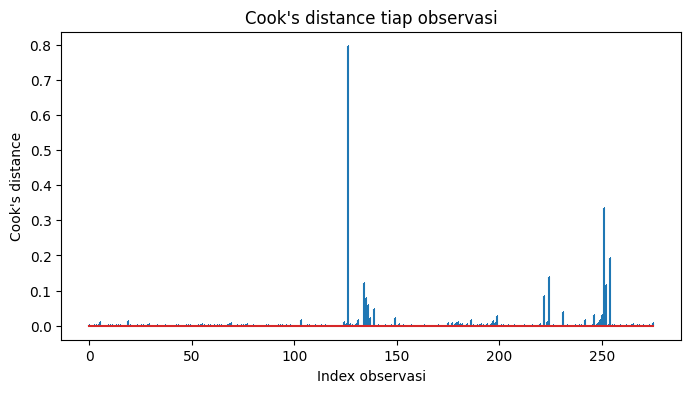

Observasi dengan Cook's distance tertinggi: index 126, nilai 0.7971


In [23]:
influence = model_98105.get_influence()
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
ax.set_xlabel("Index observasi")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's distance tiap observasi")
plt.show()

print(f"Observasi dengan Cook's distance tertinggi: index {np.argmax(cooks_d)}, nilai {cooks_d.max():.4f}")

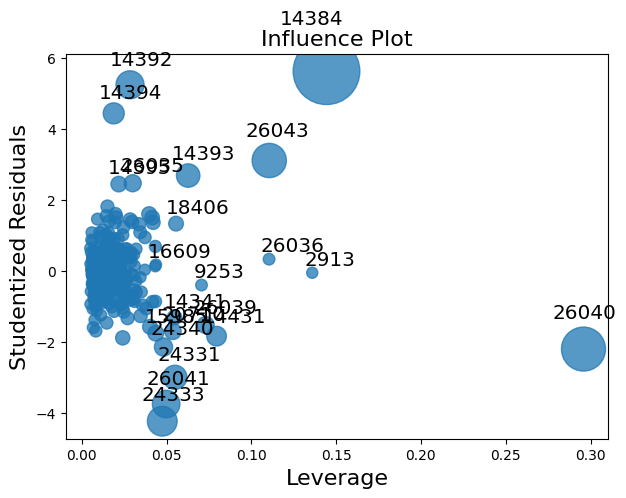

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sm.graphics.influence_plot(model_98105, ax=ax, criterion="cooks")
plt.show()

Plot ini menggabungkan leverage (sumbu x), standardized residual (sumbu y), dan Cook's distance (ukuran bubble) sekaligus. Titik dengan bubble besar di posisi ekstrem adalah kandidat kuat sebagai influential value yang layak diperiksa lebih lanjut, karena bisa jadi itu kesalahan input data, atau justru kasus unik yang perlu ditangani terpisah.

### Heteroskedasticity, Non-Normality, dan Correlated Errors

Regresi linear mengasumsikan residual punya sebaran yang relatif konstan di semua rentang prediksi (**homoskedastisitas**) dan mendekati distribusi normal. Pelanggaran asumsi ini tidak selalu membuat model gagal dipakai, tapi bisa membuat confidence interval dan p-value-nya tidak lagi akurat.

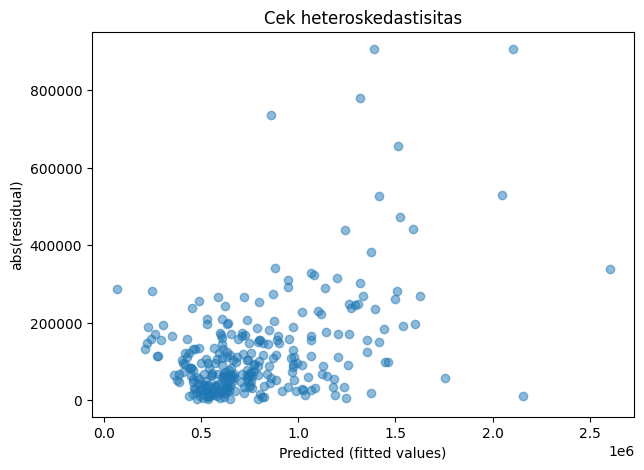

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(model_98105.fittedvalues, residuals_98105.abs(), alpha=0.5)
ax.set_xlabel("Predicted (fitted values)")
ax.set_ylabel("abs(residual)")
ax.set_title("Cek heteroskedastisitas")
plt.show()


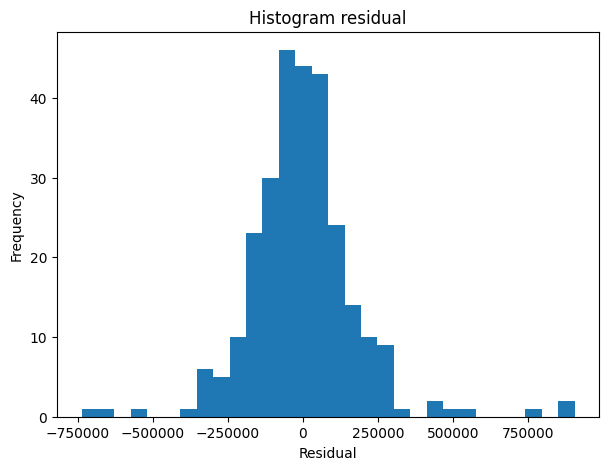

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals_98105, bins=30)
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Histogram residual")
plt.show()


Kalau titik-titik pada plot kiri cenderung makin menyebar lebar di satu sisi (biasanya di prediksi yang lebih tinggi), itu tanda heteroskedastisitas: variabilitas error-nya tidak konstan. Histogram di kanan dipakai untuk mengecek kewajaran asumsi normalitas residual; residual yang jauh dari bentuk lonceng simetris bisa jadi tanda model masih kehilangan sesuatu, misalnya hubungan nonlinear yang belum ditangkap.

Untuk data yang dikumpulkan berurutan dalam waktu atau ruang, ada juga asumsi bahwa error-nya **independen** (tidak saling berkorelasi). Pelanggaran ini biasa dicek dengan **Durbin-Watson statistic**, yang relevan terutama untuk data time series.

In [27]:
dw = sm.stats.stattools.durbin_watson(residuals_98105)
print(f"Durbin-Watson statistic: {dw:.3f}")


Durbin-Watson statistic: 1.498


### Partial Residual Plots dan Nonlinearitas

**Partial residual plot** menunjukkan hubungan antara satu predictor dan response, setelah pengaruh predictor lain "dikeluarkan" lebih dulu dari persamaan. Plot ini berguna untuk melihat apakah hubungan predictor itu benar-benar linear, atau sebenarnya melengkung dan belum ditangkap dengan baik oleh model linear biasa.

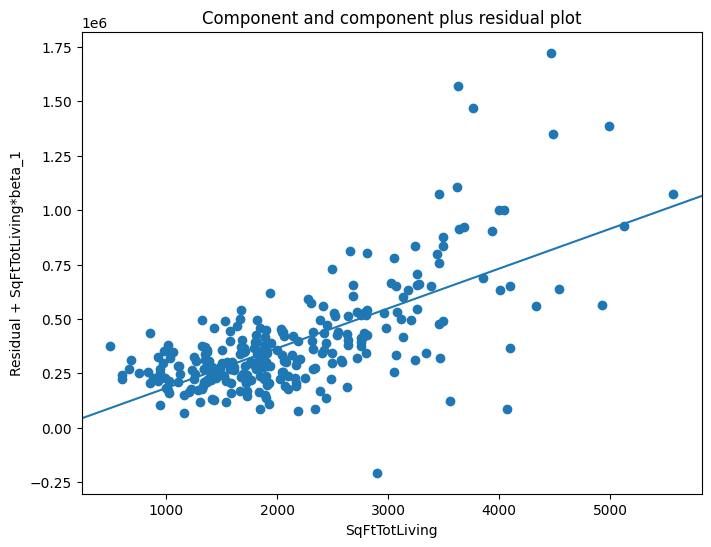

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.plot_ccpr(model_98105, "SqFtTotLiving", ax=ax)
plt.show()

Kalau garis smoothing (biasanya ditampilkan putus-putus) pada plot ini melengkung menjauh dari garis linear modelnya, itu tanda hubungan `SqFtTotLiving` terhadap harga sebenarnya tidak sepenuhnya linear, misalnya menambah luas pada rumah kecil mungkin berdampak beda dibanding menambah luas yang sama pada rumah yang sudah besar. Ini mengarah ke solusi di bagian terakhir bab ini.

## 7. Polynomial dan Spline Regression

Kalau hubungan antara predictor dan response tidak linear, salah satu solusinya adalah menambahkan suku **polynomial** (misalnya kuadrat dari predictor), atau memakai **spline**, yaitu potongan-potongan kurva (biasanya polynomial berderajat rendah) yang disambung mulus di titik-titik tertentu yang disebut **knots**.

Polynomial regression gampang diterapkan tapi punya kelemahan: kalau derajatnya terlalu tinggi, kurvanya jadi "liar" (wiggly) di ujung-ujung rentang data. Spline biasanya memberi hasil yang lebih halus dan stabil.

In [29]:
model_polinomial = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving ** 2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_polinomial.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     198.3
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.09e-95
Time:                        18:54:20   Log-Likelihood:                -3721.4
No. Observations:                 276   AIC:                             7457.
Df Residuals:                     269   BIC:                             7482.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.561e+

In [30]:
model_spline = smf.ols(
    "AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house_98105,
).fit()
print(model_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     123.3
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.34e-93
Time:                        18:54:23   Log-Likelihood:                -3715.7
No. Observations:                 276   AIC:                             7453.
Df Residuals:                     265   BIC:                             7493.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


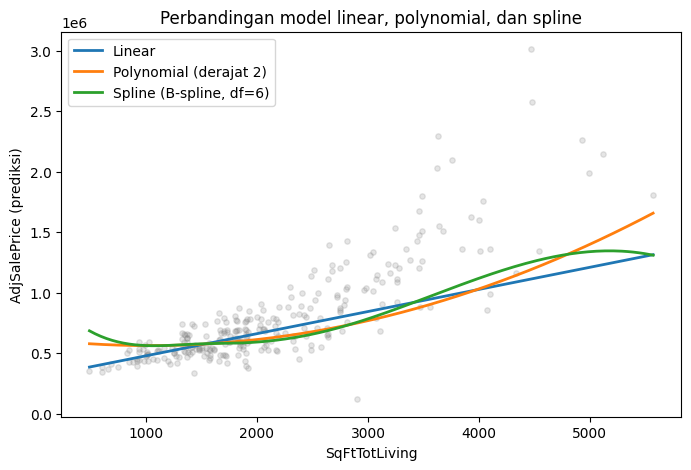

In [31]:
sqft_range = pd.DataFrame({
    "SqFtTotLiving": np.linspace(house_98105["SqFtTotLiving"].min(), house_98105["SqFtTotLiving"].max(), 200),
    "SqFtLot": house_98105["SqFtLot"].median(),
    "Bathrooms": house_98105["Bathrooms"].median(),
    "Bedrooms": house_98105["Bedrooms"].median(),
    "BldgGrade": house_98105["BldgGrade"].median(),
})

pred_linear = model_98105.predict(sqft_range)
pred_poly = model_polinomial.predict(sqft_range)
pred_spline = model_spline.predict(sqft_range)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(house_98105["SqFtTotLiving"], house_98105["AdjSalePrice"], alpha=0.2, s=15, color="gray")
ax.plot(sqft_range["SqFtTotLiving"], pred_linear, label="Linear", linewidth=2)
ax.plot(sqft_range["SqFtTotLiving"], pred_poly, label="Polynomial (derajat 2)", linewidth=2)
ax.plot(sqft_range["SqFtTotLiving"], pred_spline, label="Spline (B-spline, df=6)", linewidth=2)
ax.set_xlabel("SqFtTotLiving")
ax.set_ylabel("AdjSalePrice (prediksi)")
ax.set_title("Perbandingan model linear, polynomial, dan spline")
ax.legend()
plt.show()

Dari perbandingan ini biasanya terlihat garis linear tidak menangkap kelengkungan hubungan di ujung-ujung rentang data, sementara polynomial dan spline lebih fleksibel mengikuti pola sebenarnya. Spline cenderung lebih stabil dibanding polynomial derajat tinggi, karena tiap segmennya hanya perlu menyesuaikan diri secara lokal, bukan memaksa satu kurva tunggal mengikuti seluruh rentang data sekaligus.

Pendekatan yang lebih fleksibel lagi dari spline adalah **Generalized Additive Models (GAM)**, yang memodelkan hubungan nonlinear secara otomatis tanpa perlu menentukan derajat polynomial atau posisi knot secara manual, tapi topik ini tidak dibahas mendalam lagi di buku ini.

## 8. Generalized Additive Models (GAM)

Buku memperkenalkan **Generalized Additive Models (GAM)** sebagai cara yang lebih fleksibel untuk memodelkan hubungan nonlinear. GAM dapat mencari bentuk spline tanpa kita menentukan knot secara manual seperti pada contoh spline sebelumnya.

Implementasi Python di buku menggunakan `pyGAM`. Karena library tersebut tidak selalu terpasang di lingkungan notebook, bagian ini dibuat sebagai contoh opsional.


In [32]:
# Opsional: jalankan jika pyGAM sudah terpasang.
# Jika belum, instal terlebih dahulu di environment sendiri.
#
# from pygam import LinearGAM, s, l
#
# X = house_98105[predictors].values
# y = house_98105["AdjSalePrice"]
#
# gam = LinearGAM(
#     s(0, n_splines=12) +
#     l(1) + l(2) + l(3) + l(4)
# )
# gam.gridsearch(X, y)
# gam.summary()


## Poin-poin Penting Bab 4

- **Simple linear regression** memodelkan hubungan response dan satu predictor sebagai garis.
- **Least squares** memilih koefisien yang meminimalkan residual sum of squares.
- **Multiple linear regression** memperluas model ke beberapa predictor; koefisien dibaca dengan asumsi predictor lain tetap konstan.
- Untuk menilai model, **RMSE** dan **R²** merupakan ukuran penting; untuk tujuan prediksi, validasi pada data yang tidak digunakan untuk fitting juga penting.
- **Cross-validation** membantu memperkirakan performa model pada data baru.
- **Weighted regression** memberi bobot berbeda pada observasi ketika ada alasan analitis untuk melakukannya.
- **Prediction** harus dibedakan dari **explanation**, dan regresi tidak dengan sendirinya membuktikan hubungan sebab-akibat.
- **Confidence interval** mengukur ketidakpastian estimasi rata-rata/parameter, sedangkan **prediction interval** berkaitan dengan satu observasi baru dan biasanya lebih lebar.
- **Extrapolation** di luar rentang data dapat menghasilkan prediksi yang tidak dapat diandalkan.
- Variabel kategorikal dapat direpresentasikan sebagai **dummy variables**; untuk P kategori pada regresi dengan intercept biasanya digunakan P−1 dummy sebagai reference coding.
- **Correlated predictors**, **multicollinearity**, **confounding**, dan **interactions** memengaruhi interpretasi koefisien.
- **Regression diagnostics** digunakan untuk memeriksa outlier, influential values, heteroskedasticity, non-normality, correlated errors, dan nonlinearitas.
- Jika hubungan tidak linear, **polynomial regression**, **splines**, atau **GAM** dapat digunakan.

**Referensi utama:** Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition, Chapter 4: Regression and Prediction. O'Reilly Media.

**Dataset:** `house_sales.csv` dari repositori data resmi buku.
